# Project 2 — Binary Classification with Imbalanced Data

This notebook studies binary classification when one class is rarer or more costly to miss. The main theme is that accuracy alone can be misleading; threshold choice and class-specific metrics matter.

## Theoretical background: binary classification under class imbalance

Binary classification assigns each sample to one of two classes. Many classifiers internally estimate a **score** or **probability**, and the final class label is obtained by applying a threshold. The default threshold of 0.5 is convenient, but it is not automatically optimal.

In imbalanced problems, one class is much more common than the other. A classifier can obtain high accuracy by mostly predicting the majority class, while still failing on the class that matters most. This is why **precision**, **recall**, **F1-score**, **ROC-AUC**, and **PR-AUC** are essential. Precision asks how many predicted positives are actually positive; recall asks how many true positives are recovered. PR-AUC is especially useful when the positive class is rare because it focuses on the quality of positive predictions.

**Logistic Regression** learns a linear decision boundary in the transformed feature space and maps scores through a sigmoid function. Regularization controls coefficient magnitude. **Decision Trees** learn rule-based splits and can overfit when allowed to grow too deeply. **Random Forests** average many trees to reduce variance. **SVMs** seek a boundary with a large margin; with an RBF kernel, they can model nonlinear boundaries, but `C` and `gamma` strongly affect complexity.

Imbalance can be handled in several ways: adjusting the threshold, using class weights, undersampling the majority class, oversampling the minority class, or using synthetic methods such as SMOTE. These methods must be applied only to the training data; otherwise, validation and test scores become over-optimistic due to leakage.

## Prerequisites

This notebook assumes basic knowledge of train/test split, classification labels, and common metrics. The code is executable from top to bottom.

## Problem statement

Given patient/sample features, predict whether a sample belongs to the positive class while handling class imbalance and threshold-dependent decisions.

## Dataset description and source

The Breast Cancer Wisconsin dataset is loaded directly using `sklearn.datasets.load_breast_cancer`. To make the imbalance problem clearer, the malignant class is downsampled in a controlled way. This creates a realistic experiment where the positive class is rarer.

The notebook begins by importing the scientific Python stack, setting a reproducible random seed, and configuring plots. Keeping these imports together makes the workflow easier to rerun and debug.

In [1]:
# Optional: run this only if your environment is missing packages.
# !pip install numpy pandas matplotlib seaborn scikit-learn

import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, learning_curve, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.base import clone

The Breast Cancer dataset is loaded directly from scikit-learn. The initial checks show the number of observations, feature columns, target labels, and whether the task is suitable for classification experiments.

In [2]:
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
# Original target: 0=malignant, 1=benign. We define positive class as malignant.
df["target"] = (df["target"] == 0).astype(int)

# Create controlled imbalance: keep all negative class, downsample positive class.
pos = df[df["target"] == 1]
neg = df[df["target"] == 0]
pos_down = resample(pos, replace=False, n_samples=max(35, int(0.35 * len(pos))), random_state=RANDOM_STATE)
df_imb = pd.concat([neg, pos_down], axis=0).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X = df_imb.drop(columns="target")
y = df_imb["target"]
display(df_imb.head())
print("Shape:", df_imb.shape)
print("Class mapping: 1 = malignant/positive, 0 = benign/negative")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.46,39.28,113.40,920.6,0.09812,0.12980,0.14170,0.088110,0.1809,0.05966,...,44.87,141.20,1408.0,0.1365,0.37350,0.32410,0.20660,0.2853,0.08496,1
1,10.90,12.96,68.69,366.8,0.07515,0.03718,0.00309,0.006588,0.1442,0.05743,...,18.20,78.07,470.0,0.1171,0.08294,0.01854,0.03953,0.2738,0.07685,0
2,14.64,16.85,94.21,666.0,0.08641,0.06698,0.05192,0.027910,0.1409,0.05355,...,25.44,106.00,831.0,0.1142,0.20700,0.24370,0.07828,0.2455,0.06596,0
3,13.27,14.76,84.74,551.7,0.07355,0.05055,0.03261,0.026480,0.1386,0.05318,...,22.35,104.50,830.6,0.1006,0.12380,0.13500,0.10010,0.2027,0.06206,0
4,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.097910,0.1752,0.05533,...,38.25,155.00,1731.0,0.1166,0.19220,0.32150,0.16280,0.2572,0.06637,1


Shape: (431, 31)
Class mapping: 1 = malignant/positive, 0 = benign/negative


### Analytical interpretation

The dataset is clean and compact, which makes it suitable for repeated experiments. The class proportions should be checked before interpreting accuracy because imbalance can make a naive classifier look better than it really is.

## EDA and class distribution

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

,count,percentage
0,357,82.830626
1,74,17.169374


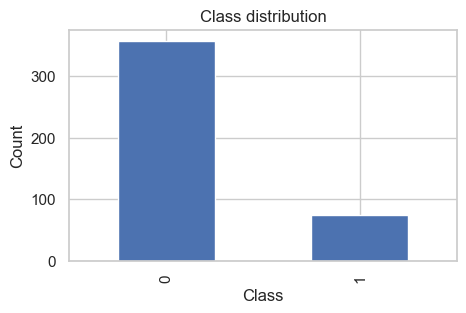

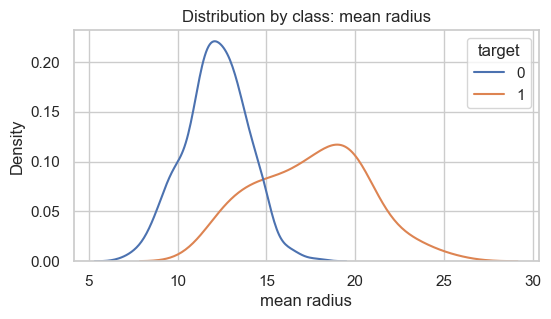

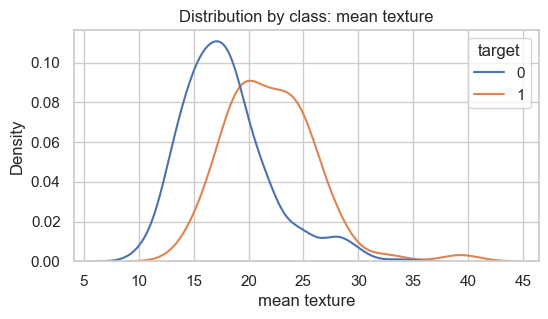

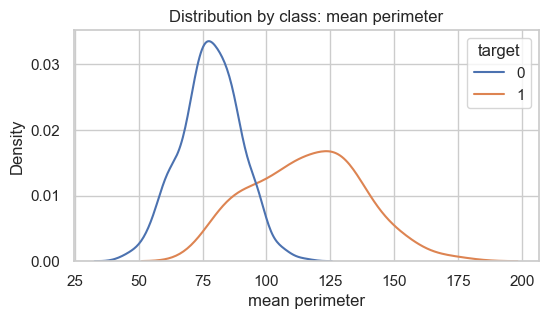

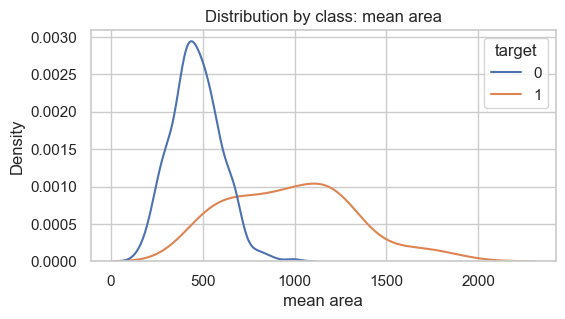

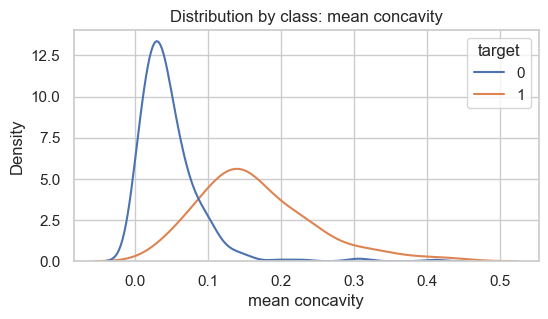

In [3]:
class_counts = y.value_counts().sort_index()
display(pd.DataFrame({"count": class_counts, "percentage": 100 * class_counts / len(y)}))
class_counts.plot(kind="bar", figsize=(5, 3), title="Class distribution")
plt.xlabel("Class"); plt.ylabel("Count"); plt.show()

selected_features = ["mean radius", "mean texture", "mean perimeter", "mean area", "mean concavity"]
for col in selected_features:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(data=df_imb, x=col, hue="target", common_norm=False)
    plt.title(f"Distribution by class: {col}")
    plt.show()

### Analytical interpretation

The class distribution confirms the imbalance. This justifies using stratified splitting, PR-AUC, F1, and threshold analysis rather than relying on accuracy alone.

The correlation heatmap summarizes linear associations among features and the target. Strong feature-feature correlations are especially relevant for coefficient interpretation and regularized linear models.

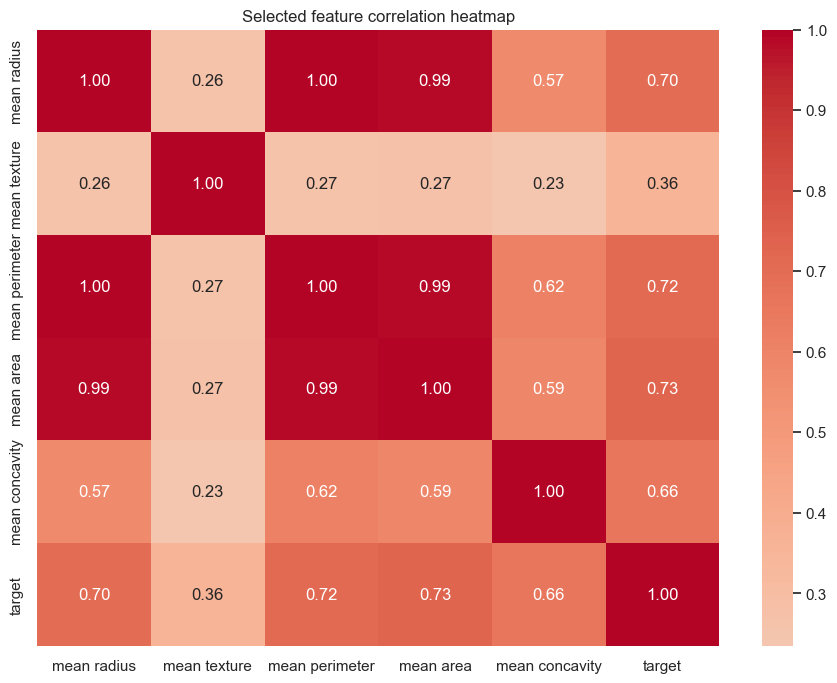

In [4]:
plt.figure(figsize=(11, 8))
sns.heatmap(df_imb[selected_features + ["target"]].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Selected feature correlation heatmap")
plt.show()

### Analytical interpretation

The heatmap helps identify redundant predictors and strong linear associations. When predictors are correlated, coefficient-based interpretation becomes less direct because multiple variables may share the same explanatory signal.

## Train/validation/test split with stratification

Stratification preserves class proportions in each split, which is important when the positive class is rare.

The data are split into separate partitions so that model selection and final evaluation remain distinct. This separation prevents the test set from influencing hyperparameter choices.

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
for name, labels in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(name, labels.value_counts(normalize=True).sort_index().round(3).to_dict())

train {0: 0.829, 1: 0.171}
validation {0: 0.826, 1: 0.174}
test {0: 0.828, 1: 0.172}


### Analytical interpretation

The split sizes confirm that training, validation, and testing are separated. The validation set supports model selection, while the final test set should be used only after the modeling decisions are fixed.

This cell varies the decision threshold and records how the error trade-off changes. The purpose is to choose a threshold based on the objective, not to assume that 0.5 is always appropriate.

In [6]:
def binary_metrics(y_true, y_pred, y_score=None):
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        out["ROC_AUC"] = roc_auc_score(y_true, y_score)
        out["PR_AUC"] = average_precision_score(y_true, y_score)
    return out

def get_positive_scores(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return scores
    return None

def evaluate_binary_model(name, model, X_train, y_train, X_val, y_val, threshold=0.5, fit=True):
    start = time.time()
    if fit:
        model.fit(X_train, y_train)
    runtime = time.time() - start
    val_score = get_positive_scores(model, X_val)
    if val_score is not None and hasattr(model, "predict_proba"):
        val_pred = (val_score >= threshold).astype(int)
    else:
        val_pred = model.predict(X_val)
    row = {"Model": name, "Threshold": threshold, "Runtime_sec": runtime}
    row.update(binary_metrics(y_val, val_pred, val_score))
    return row

## Why accuracy can be misleading

A majority-class classifier can achieve apparently reasonable accuracy while completely failing to detect the minority positive class.

The baseline model is fitted before any serious model. Its score defines the minimum level that later models must exceed to demonstrate that they have learned useful structure.

              precision    recall  f1-score   support

           0       0.83      1.00      0.90        71
           1       0.00      0.00      0.00        15

    accuracy                           0.83        86
   macro avg       0.41      0.50      0.45        86
weighted avg       0.68      0.83      0.75        86



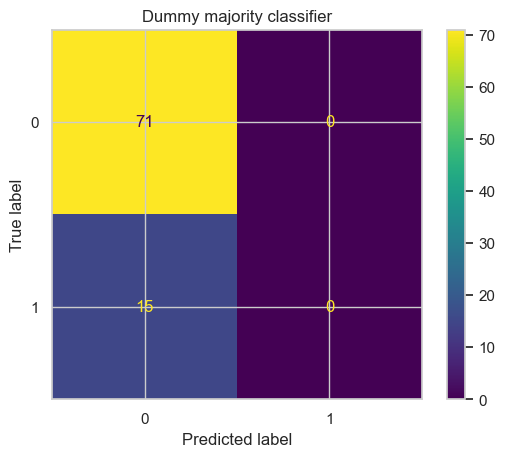

In [7]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_val)
print(classification_report(y_val, dummy_pred, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_val, dummy_pred)
plt.title("Dummy majority classifier")
plt.show()

### Analytical interpretation

The dummy classifier shows why baseline choice matters. In imbalanced classification, a majority-class rule can achieve deceptively high accuracy while producing very poor recall for the minority or positive class.

## Logistic Regression baseline

Logistic regression provides a strong interpretable baseline when scaled features are used.

The classification report and confusion matrix break performance into error types. This is more informative than accuracy alone, especially when classes are imbalanced or specific mistakes are more costly.

              precision    recall  f1-score   support

           0       1.00      0.99      0.99        71
           1       0.94      1.00      0.97        15

    accuracy                           0.99        86
   macro avg       0.97      0.99      0.98        86
weighted avg       0.99      0.99      0.99        86

{'Accuracy': 0.9883720930232558, 'Precision': 0.9375, 'Recall': 1.0, 'F1': 0.967741935483871, 'ROC_AUC': 1.0, 'PR_AUC': 1.0}


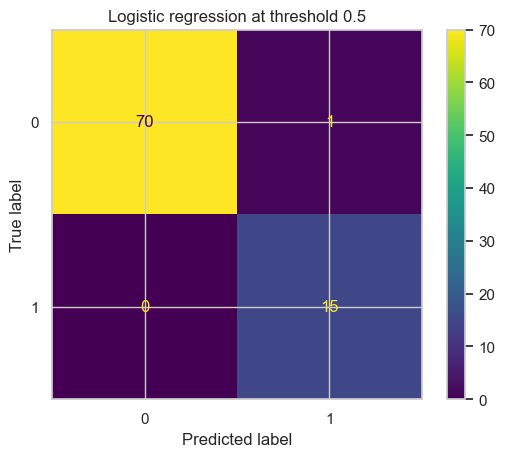

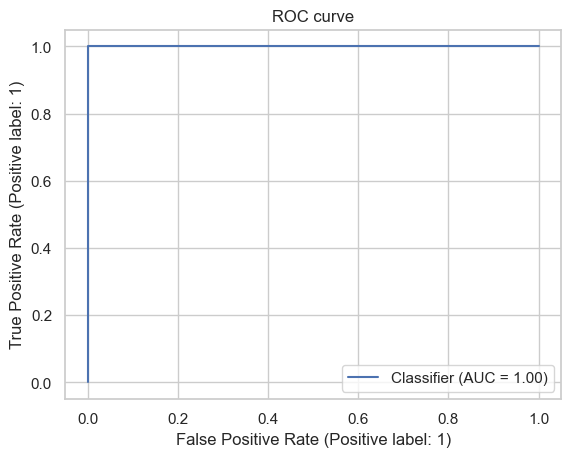

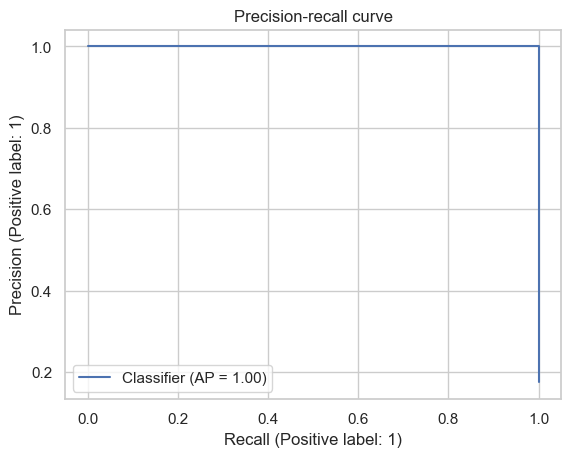

In [8]:
logreg = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)
val_score = logreg.predict_proba(X_val)[:, 1]
val_pred = (val_score >= 0.5).astype(int)
print(classification_report(y_val, val_pred, zero_division=0))
print(binary_metrics(y_val, val_pred, val_score))
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Logistic regression at threshold 0.5")
plt.show()
RocCurveDisplay.from_predictions(y_val, val_score)
plt.title("ROC curve")
plt.show()
PrecisionRecallDisplay.from_predictions(y_val, val_score)
plt.title("Precision-recall curve")
plt.show()

### Analytical interpretation

The confusion matrix and report identify which class or error type drives the score. For imbalanced data, recall and precision for the positive/minority class are more informative than accuracy alone.

## Logistic Regression hyperparameter analysis: regularization `C`

Small `C` means stronger regularization. Large `C` allows larger coefficients and can overfit.

The regularization strength of logistic regression is varied through `C`. This exposes how coefficient flexibility affects generalization and whether the model benefits from weaker or stronger regularization.

,C,coef_norm,train_F1,val_F1,train_ROC_AUC,val_ROC_AUC
0,0.001,0.176204,0.274510,0.125000,0.984813,0.993427
1,0.010,0.566604,0.857143,0.846154,0.990654,1.000000
2,0.100,1.292929,0.939759,1.000000,0.996283,1.000000
3,1.000,2.843381,0.965517,0.967742,0.999257,1.000000
4,10.000,6.823542,0.988506,0.937500,1.000000,0.999061
5,100.000,13.685404,1.000000,0.909091,1.000000,0.998122


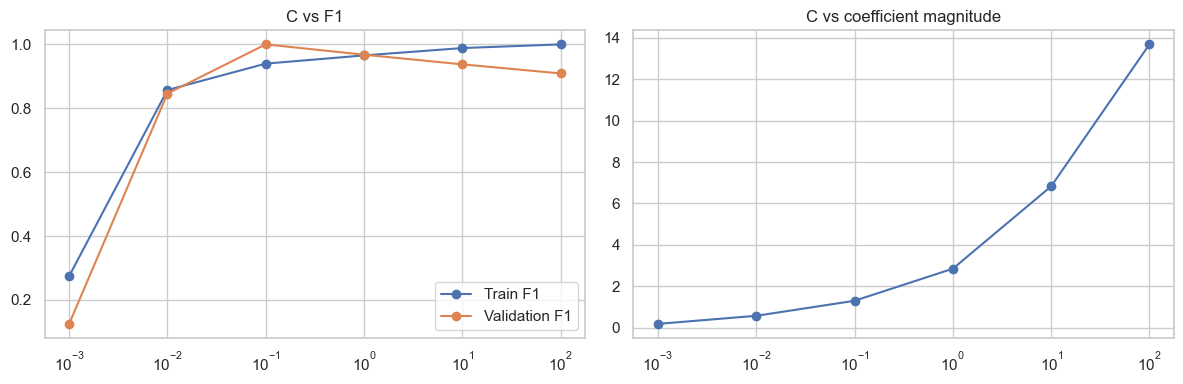

In [9]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
log_rows = []
for C in C_values:
    model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(C=C, max_iter=5000, random_state=RANDOM_STATE))])
    model.fit(X_train, y_train)
    train_scores = model.predict_proba(X_train)[:, 1]
    val_scores = model.predict_proba(X_val)[:, 1]
    train_pred = (train_scores >= 0.5).astype(int)
    val_pred = (val_scores >= 0.5).astype(int)
    coef_norm = np.linalg.norm(model.named_steps["model"].coef_)
    log_rows.append({
        "C": C, "coef_norm": coef_norm,
        "train_F1": f1_score(y_train, train_pred), "val_F1": f1_score(y_val, val_pred),
        "train_ROC_AUC": roc_auc_score(y_train, train_scores), "val_ROC_AUC": roc_auc_score(y_val, val_scores)
    })
log_df = pd.DataFrame(log_rows)
display(log_df)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogx(log_df["C"], log_df["train_F1"], marker="o", label="Train F1")
axes[0].semilogx(log_df["C"], log_df["val_F1"], marker="o", label="Validation F1")
axes[0].legend(); axes[0].set_title("C vs F1")
axes[1].semilogx(log_df["C"], log_df["coef_norm"], marker="o")
axes[1].set_title("C vs coefficient magnitude")
plt.tight_layout(); plt.show()

### Analytical interpretation

The `C` curve shows whether the linear classifier needs stronger or weaker regularization. If validation performance changes little across a range, the simpler and more stable region is usually preferable to an extreme value.

### Interpretation guide

A useful `C` is not necessarily the one with the highest training score. Look for validation performance, stable behavior, and reasonable coefficient size.

## Threshold tuning

The model outputs probabilities. The threshold turns probabilities into final class decisions. The default threshold 0.5 is not always aligned with the real objective.

This cell varies the decision threshold and records how the error trade-off changes. The purpose is to choose a threshold based on the objective, not to assume that 0.5 is always appropriate.

,threshold,precision,recall,F1,accuracy
0,0.05,0.625000,1.000000,0.769231,0.895349
1,0.10,0.681818,1.000000,0.810811,0.918605
2,0.15,0.714286,1.000000,0.833333,0.930233
3,0.20,0.750000,1.000000,0.857143,0.941860
4,0.25,0.882353,1.000000,0.937500,0.976744
5,0.30,0.937500,1.000000,0.967742,0.988372
6,0.35,0.937500,1.000000,0.967742,0.988372
7,0.40,0.937500,1.000000,0.967742,0.988372
8,0.45,0.937500,1.000000,0.967742,0.988372
9,0.50,0.937500,1.000000,0.967742,0.988372


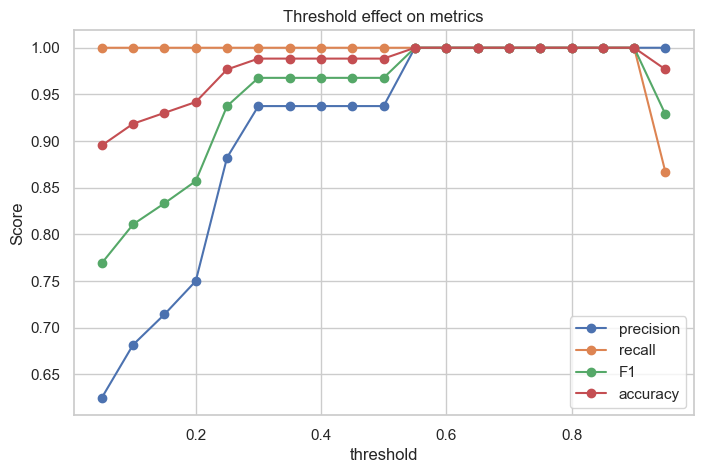

In [10]:
thresholds = np.round(np.linspace(0.05, 0.95, 19), 2)
th_rows = []
for th in thresholds:
    pred = (val_score >= th).astype(int)
    th_rows.append({
        "threshold": th,
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "F1": f1_score(y_val, pred, zero_division=0),
        "accuracy": accuracy_score(y_val, pred)
    })
th_df = pd.DataFrame(th_rows)
display(th_df)
th_df.plot(x="threshold", y=["precision", "recall", "F1", "accuracy"], marker="o", figsize=(8, 5))
plt.title("Threshold effect on metrics")
plt.ylabel("Score")
plt.show()

### Analytical interpretation

The threshold curve demonstrates that precision, recall, F1, and cost cannot all be optimized at the same operating point. A lower threshold is preferable when missing positives is costly; a higher threshold is preferable when false alarms are costly.

## Decision Tree hyperparameter analysis

Tree complexity is varied manually through depth or leaf-size parameters. Comparing training and validation scores shows whether the tree is too simple, reasonably balanced, or overfitting.

split,train,validation
max_depth,,
1,0.876404,0.866667
2,0.931818,0.903226
3,0.964706,0.903226
4,1.000000,0.848485
5,1.000000,0.848485
None,1.000000,0.848485


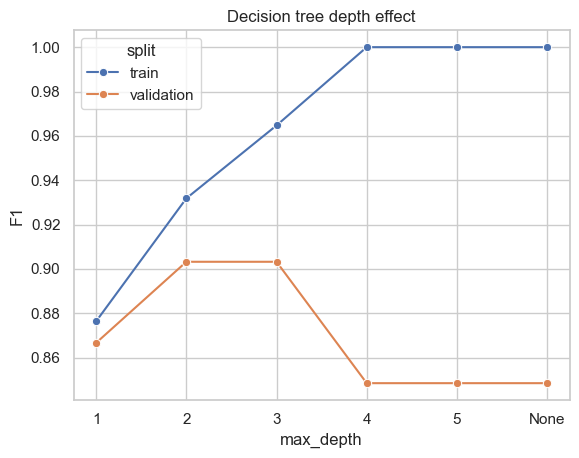

,min_samples_leaf,Accuracy,Precision,Recall,F1
0,1,0.941860,0.777778,0.933333,0.848485
1,3,0.930233,0.736842,0.933333,0.823529
2,5,0.965116,0.875000,0.933333,0.903226
3,10,0.953488,0.923077,0.800000,0.857143
4,20,0.953488,0.866667,0.866667,0.866667


In [11]:
tree_rows = []
for depth in [1, 2, 3, 4, 5, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    for split, Xs, ys in [("train", X_train, y_train), ("validation", X_val, y_val)]:
        pred = model.predict(Xs)
        tree_rows.append({"max_depth": str(depth), "split": split, "F1": f1_score(ys, pred), "accuracy": accuracy_score(ys, pred)})
tree_df = pd.DataFrame(tree_rows)
display(tree_df.pivot(index="max_depth", columns="split", values="F1"))
sns.lineplot(data=tree_df, x="max_depth", y="F1", hue="split", marker="o")
plt.title("Decision tree depth effect")
plt.show()

leaf_rows = []
for leaf in [1, 3, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    leaf_rows.append({"min_samples_leaf": leaf, **binary_metrics(y_val, pred)})
display(pd.DataFrame(leaf_rows))

### Analytical interpretation

The tree experiments should show the classic complexity pattern: shallow trees underfit, while very deep trees often achieve high training performance with weaker validation behavior. Leaf-size constraints usually improve stability by preventing tiny, highly specific terminal regions.

## Random Forest hyperparameter analysis

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

,n_estimators,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Runtime_sec
0,10,0.988372,0.9375,1.0,0.967742,0.999531,0.995833,0.066200
1,50,1.000000,1.0000,1.0,1.000000,1.000000,1.000000,0.144533
2,100,1.000000,1.0000,1.0,1.000000,1.000000,1.000000,0.238101
3,200,1.000000,1.0000,1.0,1.000000,1.000000,1.000000,0.395547


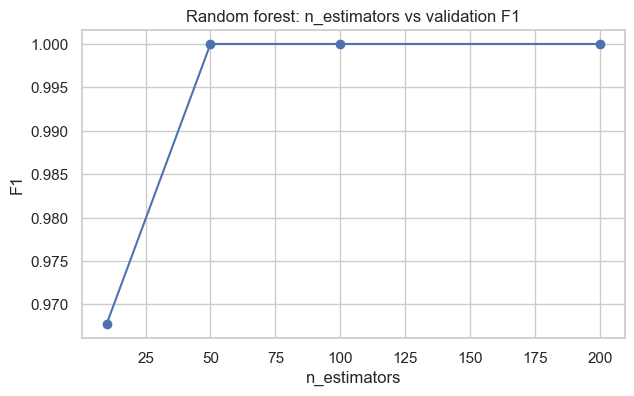


 max_depth


,max_depth,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,2,0.976744,1.0,0.866667,0.928571,1.0,1.0
1,4,1.000000,1.0,1.000000,1.000000,1.0,1.0
2,6,1.000000,1.0,1.000000,1.000000,1.0,1.0
3,None,1.000000,1.0,1.000000,1.000000,1.0,1.0



 min_samples_leaf


,min_samples_leaf,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,1,1.000000,1.0,1.000000,1.000000,1.0,1.0
1,3,1.000000,1.0,1.000000,1.000000,1.0,1.0
2,5,1.000000,1.0,1.000000,1.000000,1.0,1.0
3,10,0.988372,1.0,0.933333,0.965517,1.0,1.0


In [12]:
rf_rows = []
for n in [10, 50, 100, 200]:
    model = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE, n_jobs=-1)
    row = evaluate_binary_model(f"RF n={n}", model, X_train, y_train, X_val, y_val)
    row["n_estimators"] = n
    rf_rows.append(row)
rf_df = pd.DataFrame(rf_rows)
display(rf_df[["n_estimators", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Runtime_sec"]])
plt.figure(figsize=(7, 4))
plt.plot(rf_df["n_estimators"], rf_df["F1"], marker="o")
plt.title("Random forest: n_estimators vs validation F1")
plt.xlabel("n_estimators"); plt.ylabel("F1")
plt.show()

for param, values in {"max_depth": [2, 4, 6, None], "min_samples_leaf": [1, 3, 5, 10]}.items():
    rows=[]
    for v in values:
        kwargs={param: v}
        model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, **kwargs)
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
        rows.append({param: str(v), **binary_metrics(y_val, pred, model.predict_proba(X_val)[:,1])})
    print("\n", param)
    display(pd.DataFrame(rows))

### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

## SVM classifier: `C` and `gamma`

SVMs need scaling. With an RBF kernel, `gamma` controls how local the decision boundary is. `C` controls how strongly the model penalizes margin violations.

SVM hyperparameters are studied manually. Since SVMs depend on distances and margins, scaling and the choice of `C` and `gamma` strongly influence the learned boundary.

In [13]:
svm_rows = []
for C in [0.01, 0.1, 1, 10, 100]:
    model = Pipeline([("scaler", StandardScaler()), ("model", SVC(C=C, kernel="rbf", gamma="scale", probability=True, random_state=RANDOM_STATE))])
    row = evaluate_binary_model(f"SVM C={C}", model, X_train, y_train, X_val, y_val)
    row["C"] = C
    svm_rows.append(row)
svm_df = pd.DataFrame(svm_rows)
display(svm_df[["C", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]])

gamma_rows = []
for gamma in [0.001, 0.01, 0.1, 1]:
    model = Pipeline([("scaler", StandardScaler()), ("model", SVC(C=1, kernel="rbf", gamma=gamma, probability=True, random_state=RANDOM_STATE))])
    row = evaluate_binary_model(f"SVM gamma={gamma}", model, X_train, y_train, X_val, y_val)
    row["gamma"] = gamma
    gamma_rows.append(row)
display(pd.DataFrame(gamma_rows)[["gamma", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]])

,C,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.01,0.976744,0.882353,1.0,0.937500,1.000000,1.000000
1,0.10,0.976744,0.882353,1.0,0.937500,1.000000,1.000000
2,1.00,0.988372,0.937500,1.0,0.967742,1.000000,1.000000
3,10.00,0.988372,0.937500,1.0,0.967742,1.000000,1.000000
4,100.00,0.988372,0.937500,1.0,0.967742,0.999061,0.995833


,gamma,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,0.001,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000
1,0.010,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000
2,0.100,0.988372,0.9375,1.000000,0.967742,1.000000,1.000000
3,1.000,0.837209,1.0000,0.066667,0.125000,0.979343,0.868687


### Analytical interpretation

The SVM results should be interpreted through boundary complexity. Very small `C` or very small `gamma` can underfit; very large values can create overly local boundaries. A good setting balances margin flexibility with validation stability.

## Handling imbalance without leakage

Resampling is applied only to the training set. Validation and test data must reflect the real evaluation distribution.

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

In [14]:
def random_oversample(X_train, y_train):
    train_df = X_train.copy()
    train_df["target"] = y_train.values
    majority = train_df[train_df["target"] == 0]
    minority = train_df[train_df["target"] == 1]
    minority_up = resample(minority, replace=True, n_samples=len(majority), random_state=RANDOM_STATE)
    balanced = pd.concat([majority, minority_up]).sample(frac=1, random_state=RANDOM_STATE)
    return balanced.drop(columns="target"), balanced["target"]

def random_undersample(X_train, y_train):
    train_df = X_train.copy()
    train_df["target"] = y_train.values
    majority = train_df[train_df["target"] == 0]
    minority = train_df[train_df["target"] == 1]
    majority_down = resample(majority, replace=False, n_samples=len(minority), random_state=RANDOM_STATE)
    balanced = pd.concat([majority_down, minority]).sample(frac=1, random_state=RANDOM_STATE)
    return balanced.drop(columns="target"), balanced["target"]

imbalance_rows = []
models = {
    "LogReg none": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
    "LogReg class_weight": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "RF none": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "RF class_weight": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}
for name, model in models.items():
    imbalance_rows.append(evaluate_binary_model(name, model, X_train, y_train, X_val, y_val))

for method, sampler in [("oversample", random_oversample), ("undersample", random_undersample)]:
    X_res, y_res = sampler(X_train, y_train)
    model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))])
    row = evaluate_binary_model(f"LogReg {method}", model, X_res, y_res, X_val, y_val)
    imbalance_rows.append(row)

imbalance_df = pd.DataFrame(imbalance_rows).sort_values("F1", ascending=False)
display(imbalance_df[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
2,RF none,1.000000,1.000000,1.0,1.000000,1.0,1.0
3,RF class_weight,1.000000,1.000000,1.0,1.000000,1.0,1.0
0,LogReg none,0.988372,0.937500,1.0,0.967742,1.0,1.0
4,LogReg oversample,0.976744,0.882353,1.0,0.937500,1.0,1.0
1,LogReg class_weight,0.965116,0.833333,1.0,0.909091,1.0,1.0
5,LogReg undersample,0.965116,0.833333,1.0,0.909091,1.0,1.0


### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

Imbalance-handling strategies are compared using only the training data. This avoids leakage and shows whether weighting or resampling improves the minority-class objective.

In [15]:
# Optional SMOTE section. Runs only if imbalanced-learn is installed.
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    smote_model = ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ])
    smote_row = evaluate_binary_model("LogReg SMOTE", smote_model, X_train, y_train, X_val, y_val)
    display(pd.DataFrame([smote_row]))
except Exception as e:
    print("SMOTE section skipped. Install imbalanced-learn if needed. Error:", e)

SMOTE section skipped. Install imbalanced-learn if needed. Error: No module named 'imblearn'


### Analytical interpretation

The imbalance-handling comparison shows whether changing the training distribution or class weights improves the metric that matters. A method that increases recall may reduce precision, so the best choice depends on the error cost rather than accuracy alone.

## Cost-sensitive evaluation

In medical-like settings, false negatives may be more costly than false positives. The exact costs are domain-specific; this example demonstrates the calculation.

The classification report and confusion matrix break performance into error types. This is more informative than accuracy alone, especially when classes are imbalanced or specific mistakes are more costly.

,threshold,FP,FN,expected_cost
16,0.85,0,0,0
14,0.75,0,0,0
13,0.70,0,0,0
12,0.65,0,0,0
11,0.60,0,0,0


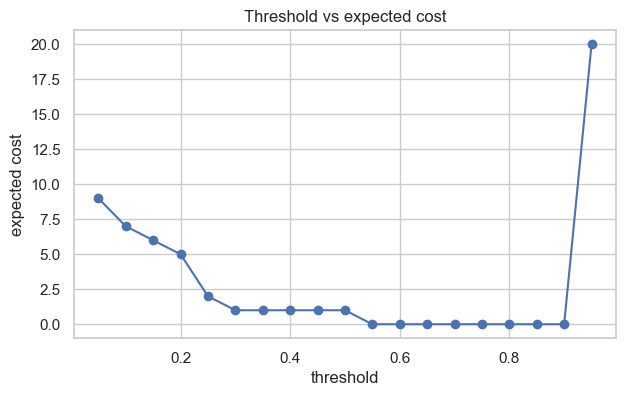

In [16]:
fn_cost = 10
fp_cost = 1
cost_rows = []
for th in thresholds:
    pred = (val_score >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    expected_cost = fp_cost * fp + fn_cost * fn
    cost_rows.append({"threshold": th, "FP": fp, "FN": fn, "expected_cost": expected_cost})
cost_df = pd.DataFrame(cost_rows)
display(cost_df.sort_values("expected_cost").head())
plt.figure(figsize=(7, 4))
plt.plot(cost_df["threshold"], cost_df["expected_cost"], marker="o")
plt.title("Threshold vs expected cost")
plt.xlabel("threshold"); plt.ylabel("expected cost")
plt.show()

### Analytical interpretation

The confusion matrix and report identify which class or error type drives the score. For imbalanced data, recall and precision for the positive/minority class are more informative than accuracy alone.

## Final model comparison on test data

The threshold should be chosen using validation behavior. The test set is used once for final estimation.

Random Forest settings are varied to study variance reduction, tree complexity, and runtime. The important pattern is whether performance stabilizes as more trees are added.

In [17]:
best_threshold = float(cost_df.sort_values("expected_cost").iloc[0]["threshold"])
final_models = {
    "LogReg threshold tuned": logreg,
    "LogReg class_weight": Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "SVM RBF": Pipeline([("scaler", StandardScaler()), ("model", SVC(C=1, kernel="rbf", gamma="scale", probability=True, random_state=RANDOM_STATE))]),
}
final_rows = []
for name, model in final_models.items():
    model.fit(X_train, y_train)
    score = get_positive_scores(model, X_test)
    th = best_threshold if name == "LogReg threshold tuned" else 0.5
    pred = (score >= th).astype(int) if score is not None and hasattr(model, "predict_proba") else model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    row = {"Model": name, "threshold": th, "expected_cost": fp_cost * fp + fn_cost * fn}
    row.update(binary_metrics(y_test, pred, score))
    final_rows.append(row)
final_df = pd.DataFrame(final_rows).sort_values("expected_cost")
display(final_df)

,Model,threshold,expected_cost,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
1,LogReg class_weight,0.50,0,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
3,SVM RBF,0.50,20,0.977011,1.0,0.866667,0.928571,0.997222,0.988889
0,LogReg threshold tuned,0.85,30,0.965517,1.0,0.800000,0.888889,1.000000,1.000000
2,Random Forest,0.50,30,0.965517,1.0,0.800000,0.888889,1.000000,1.000000


### Analytical interpretation

Random Forest performance usually improves quickly as trees are added and then stabilizes. A plateau means that adding more trees mainly increases computation. Depth and leaf-size results indicate how much complexity each individual tree should be allowed.

## Error analysis

This cell performs the computational step described in the surrounding section. Read the resulting table or plot in terms of model behavior, not only in terms of the largest score.

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,true,pred,score,error_type


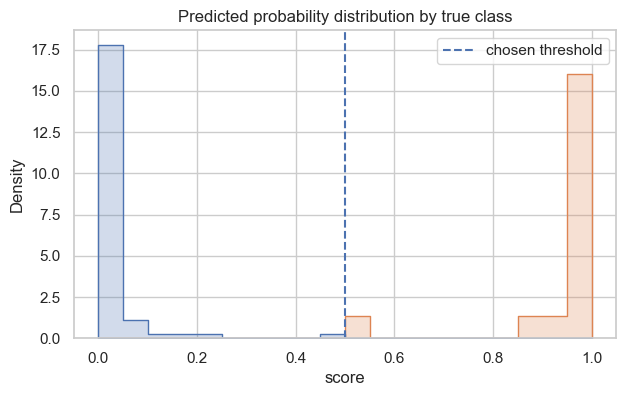

In [18]:
best_model_name = final_df.iloc[0]["Model"]
best_model = final_models[best_model_name]
score = get_positive_scores(best_model, X_test)
th = final_df.iloc[0]["threshold"]
pred = (score >= th).astype(int) if score is not None and hasattr(best_model, "predict_proba") else best_model.predict(X_test)
err = X_test.copy()
err["true"] = y_test.values
err["pred"] = pred
if score is not None:
    err["score"] = score
err["error_type"] = np.where((err["true"]==1) & (err["pred"]==0), "FN", np.where((err["true"]==0) & (err["pred"]==1), "FP", "correct"))
display(err[err["error_type"] != "correct"].head(10))

if score is not None:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=err, x="score", hue="true", bins=20, element="step", stat="density", common_norm=False)
    plt.axvline(th, linestyle="--", label="chosen threshold")
    plt.title("Predicted probability distribution by true class")
    plt.legend(); plt.show()

### Analytical interpretation

Interpret this result by comparing training and validation behavior, class-wise or target-wise errors, and the complexity of the model. The useful conclusion is the pattern in the output, not merely the numerical score.

## Additional analytical experiment: probability calibration

A classifier may rank samples well but still produce poorly calibrated probabilities. Calibration matters when probabilities are used for medical triage, risk scoring, or threshold selection. The next cell checks whether predicted probabilities align with observed frequencies.

Brier score: 0.008853302831747529


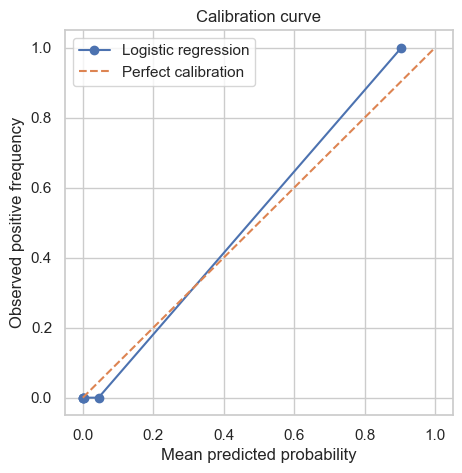

,mean_predicted_probability,observed_positive_frequency
0,0.000013,0.0
1,0.000168,0.0
2,0.000705,0.0
3,0.002778,0.0
4,0.044597,0.0
5,0.904343,1.0


In [19]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# Use the already trained logistic regression pipeline.
test_prob = logreg.predict_proba(X_test)[:, 1]
prob_true, prob_pred = calibration_curve(y_test, test_prob, n_bins=6, strategy="quantile")

print("Brier score:", brier_score_loss(y_test, test_prob))
plt.figure(figsize=(5,5))
plt.plot(prob_pred, prob_true, marker="o", label="Logistic regression")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive frequency")
plt.title("Calibration curve")
plt.legend()
plt.show()

calib_table = pd.DataFrame({"mean_predicted_probability": prob_pred, "observed_positive_frequency": prob_true})
display(calib_table)


### How to interpret this added experiment
A curve close to the diagonal indicates that predicted probabilities can be interpreted as approximate risk values. A model can have excellent ROC-AUC but still be miscalibrated. If calibration is poor, use calibration methods such as Platt scaling or isotonic regression on validation data, not on the test set.

## Interpretation

Discuss which metric matters most. A threshold or class-weight setting that improves recall may reduce precision. This is not a bug; it reflects the decision tradeoff.

## Limitations

- The imbalance was created by downsampling for teaching clarity.
- The dataset is relatively small and clean.
- The example costs are illustrative, not medical recommendations.
- Calibration was not deeply studied here.

## What we learned

This project covered accuracy limitations, confusion matrices, ROC-AUC, PR-AUC, threshold tuning, class weights, resampling, expected cost, and error analysis for imbalanced binary classification.

## Possible extensions

Try probability calibration, fairness across subgroups, anomaly-detection framing, imbalanced ensemble methods, and deployment threshold monitoring.